In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [5]:
df_train = pd.read_csv("mnist_train.xls")
df_test = pd.read_csv("mnist_test.xls")

In [6]:
df_test.head()

,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df_train.shape

(60000, 785)

In [8]:
y_train = df_train['label']
x_train = df_train.drop('label',axis=1)
y_test = df_test['label']
x_test = df_test.drop('label',axis=1)

In [9]:
type(x_train)

pandas.core.frame.DataFrame

3


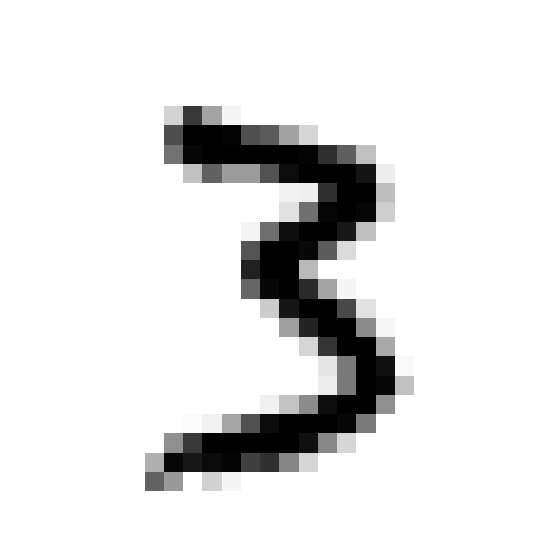

In [12]:
plt.figure(figsize=(7,7))
some_digit = 130
some_digit_image = x_train.iloc[some_digit].to_numpy()
plt.imshow(np.reshape(some_digit_image, (28,28)), cmap="binary")
plt.axis("off")
print(y_train.iloc[some_digit])

<Axes: xlabel='label', ylabel='count'>

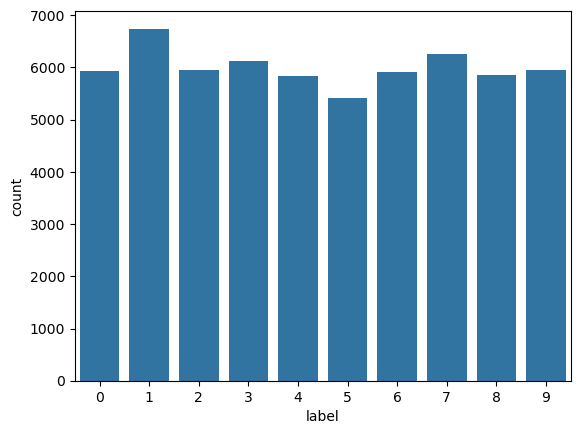

In [13]:
sns.countplot(x='label',data=df_train)

### KNN (Neighbours = 3)

In [30]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=3)
classifier.fit(x_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [31]:
y_pred1 = classifier.predict(x_test)
y_pred1

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("KNN(3) Accuracy:",accuracy_score(y_test, y_pred1))

KNN(3) Accuracy: 0.9705


In [34]:
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.96      1.00      0.98      1135
           2       0.98      0.97      0.97      1032
           3       0.96      0.97      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.96      0.96       892
           6       0.98      0.99      0.98       958
           7       0.96      0.96      0.96      1028
           8       0.99      0.94      0.96       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [35]:
print(confusion_matrix(y_test, y_pred))

[[ 955    0    3    2    1    5    6    4    4    0]
 [   0 1108    8    3    0    1    3    2   10    0]
 [   5   12  917   18   12    6   11    9   39    3]
 [   3    1   18  921    2   23    3   11   22    6]
 [   3    3    6    4  911    0   10    7   10   28]
 [  12    5    3   37   12  759   16    6   36    6]
 [   9    3    9    2    7   17  908    1    2    0]
 [   4    7   25    8    4    2    0  945    3   30]
 [   7   14    5   20    7   22   10   14  864   11]
 [   8    7    1    9   20    7    1   22   10  924]]


### KNN (Neighbours = 5) 

In [38]:
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
y_pred2 = classifier.predict(x_test)
y_pred2

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("KNN(5) Accuracy:",accuracy_score(y_test, y_pred2))

KNN(5) Accuracy: 0.9443


In [41]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.99      0.97      1135
           2       0.96      0.93      0.94      1032
           3       0.92      0.95      0.94      1010
           4       0.94      0.94      0.94       982
           5       0.93      0.92      0.93       892
           6       0.96      0.97      0.97       958
           7       0.94      0.92      0.93      1028
           8       0.96      0.90      0.93       974
           9       0.92      0.92      0.92      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



In [42]:
print(confusion_matrix(y_test, y_pred2))

[[ 963    0    1    3    1    5    6    1    0    0]
 [   0 1129    3    0    0    0    3    0    0    0]
 [  14    6  960   20    5    0    7    9   10    1]
 [   0    3    5  962    3   13    0   10   10    4]
 [   1   10    5    3  922    3    6    4    2   26]
 [   5    1    3   23    8  824   13    2    6    7]
 [  10    4    2    1    3    6  929    0    3    0]
 [   0   21   12    4    8    2    0  949    1   31]
 [  13    3    6   18    8   30    3    6  880    7]
 [   6    5    5   10   18    6    0   31    3  925]]


### Logistic Regression (C = 1.0, max_iter = 1000)

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
classifier = LogisticRegression(C=1.0, max_iter=1000)
classifier.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
y_pred3 = classifier.predict(x_test)
y_pred3

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Logistic Regression(C=1.0, max_iter = 1000) Accuracy:", accuracy_score(y_test, y_pred3))

Logistic Regression(C=1.0, max_iter = 1000) Accuracy: 0.9221


In [46]:
print(classification_report(y_test, y_pred3))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.92      0.89      0.90      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.93      0.93       982
           5       0.89      0.86      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.92      1028
           8       0.87      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [47]:
print(confusion_matrix(y_test, y_pred3))

[[ 949    0    3    4    1   11    6    3    3    0]
 [   0 1109    8    2    0    2    3    1   10    0]
 [  10    9  918   17   11    5   13    7   37    5]
 [   3    1   20  922    2   21    3   11   21    6]
 [   1    3    9    4  915    1    7    7    6   29]
 [  10    6    3   35    9  771   14    8   32    4]
 [   8    4    8    3    5   17  910    1    2    0]
 [   3    9   23    7    5    2    0  944    5   30]
 [  10   12    5   22    8   26    9    9  858   15]
 [   7    7    2    8   21    7    0   23    9  925]]


### Logistic Regression(C=1.0,max_iter = 3000)

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
classifier = LogisticRegression(C=1.0, max_iter=3000)
classifier.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [52]:
y_pred4 = classifier.predict(x_test)
y_pred4

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Logistic Regression(C=1.0, max_iter = 3000) Accuracy:", accuracy_score(y_test, y_pred4))

Logistic Regression(C=1.0, max_iter = 3000) Accuracy: 0.922


In [54]:
print(classification_report(y_test, y_pred4))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.92      0.89      0.90      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.93      0.93       982
           5       0.89      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.92      1028
           8       0.87      0.88      0.88       974
           9       0.91      0.91      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [55]:
print(confusion_matrix(y_test, y_pred4))

[[ 948    0    3    4    1   12    6    3    3    0]
 [   0 1109    8    2    0    2    3    1   10    0]
 [  10    9  919   16   11    5   13    7   37    5]
 [   3    1   20  922    2   21    3   11   21    6]
 [   1    3    9    5  914    1    7    7    6   29]
 [  10    5    3   33    9  774   14    8   32    4]
 [   8    4    8    3    5   17  910    1    2    0]
 [   3    9   23    7    5    2    0  944    5   30]
 [  10   12    5   23    8   26    9    9  857   15]
 [   7    7    2    8   21    8    0   23   10  923]]


### Logistic Regression(C=0.1,max_iter = 1000)

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
classifier = LogisticRegression(C=0.1, max_iter=1000)
classifier.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [57]:
y_pred5 = classifier.predict(x_test)
y_pred5

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [58]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Logistic Regression(C=0.1, max_iter = 1000) Accuracy:", accuracy_score(y_test, y_pred5))

Logistic Regression(C=0.1, max_iter = 1000) Accuracy: 0.9273


In [59]:
print(classification_report(y_test, y_pred5))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.91      0.92      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.89       892
           6       0.94      0.96      0.95       958
           7       0.93      0.93      0.93      1028
           8       0.88      0.89      0.88       974
           9       0.92      0.92      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [60]:
print(confusion_matrix(y_test, y_pred5))

[[ 954    0    2    2    0   10    7    4    1    0]
 [   0 1111    6    2    0    2    3    1   10    0]
 [   9    6  924   16   11    5   13    7   38    3]
 [   3    1   16  927    2   21    2   11   21    6]
 [   1    3    8    3  920    0    7    6    6   28]
 [   7    4    2   33    9  778   15    8   32    4]
 [   9    3    7    2    6   13  915    1    2    0]
 [   1    8   24    6    4    1    0  951    3   30]
 [   9   10    5   21    8   24    9   10  866   12]
 [   7    8    2    9   18    7    0   23    8  927]]


### Logistic Regression(C=0.1,max_iter = 3000)

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
classifier = LogisticRegression(C=0.1, max_iter=3000)
classifier.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [62]:
y_pred6 = classifier.predict(x_test)
y_pred6

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [63]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Logistic Regression(C=0.1, max_iter = 3000) Accuracy:", accuracy_score(y_test, y_pred6))

Logistic Regression(C=0.1, max_iter = 3000) Accuracy: 0.9273


In [64]:
print(classification_report(y_test, y_pred6))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.91      0.92      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.89       892
           6       0.94      0.96      0.95       958
           7       0.93      0.93      0.93      1028
           8       0.88      0.89      0.88       974
           9       0.92      0.92      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [65]:
print(confusion_matrix(y_test, y_pred6))

[[ 954    0    2    2    0   10    7    4    1    0]
 [   0 1111    6    2    0    2    3    1   10    0]
 [   9    6  924   16   11    5   13    7   38    3]
 [   3    1   16  927    2   21    2   11   21    6]
 [   1    3    8    3  920    0    7    6    6   28]
 [   7    4    2   33    9  778   15    8   32    4]
 [   9    3    7    2    6   13  915    1    2    0]
 [   1    8   24    6    4    1    0  951    3   30]
 [   9   10    5   21    8   24    9   10  866   12]
 [   7    8    2    9   18    7    0   23    8  927]]


### Decision Tree(gini, max_depth=10)

In [66]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=42)
classifier.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [68]:
y_pred7 = classifier.predict(x_test)
y_pred7

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [69]:
from sklearn.metrics import accuracy_score
print("Decision Tree(gini, max_depth=10) Accuracy:",accuracy_score(y_test,y_pred7))

Decision Tree(gini, max_depth=10) Accuracy: 0.8662


In [70]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred7))

              precision    recall  f1-score   support

           0       0.91      0.94      0.92       980
           1       0.95      0.96      0.95      1135
           2       0.85      0.84      0.84      1032
           3       0.82      0.84      0.83      1010
           4       0.86      0.85      0.86       982
           5       0.84      0.80      0.82       892
           6       0.91      0.87      0.89       958
           7       0.90      0.88      0.89      1028
           8       0.80      0.81      0.80       974
           9       0.81      0.86      0.83      1009

    accuracy                           0.87     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.87      0.87     10000



In [71]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred7))

[[ 918    0   10    8    6   11    7    4   13    3]
 [   1 1089   12   13    2    5    2    1   10    0]
 [  15   11  864   20   22    8   12   34   35   11]
 [   7    5   39  845    6   47    2   19   23   17]
 [   3    4    7    7  833    7   12    8   28   73]
 [  16    9    5   51   14  716   20    8   30   23]
 [  23    5   13    7   34   17  833    3   21    2]
 [   2   14   26   10   10    5    0  906   11   44]
 [   9   10   30   40   14   21   19    9  791   31]
 [  13    2    8   32   24   14    5   13   31  867]]


### Decision Tree(gini, max_depth=20)

In [72]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion="gini", max_depth=20, random_state=42)
classifier.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [73]:
y_pred8 = classifier.predict(x_test)
y_pred8

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [74]:
from sklearn.metrics import accuracy_score
print("Decision Tree(gini, max_depth=20) Accuracy:",accuracy_score(y_test,y_pred8))

Decision Tree(gini, max_depth=20) Accuracy: 0.8818


In [75]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred8))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93       980
           1       0.96      0.96      0.96      1135
           2       0.87      0.86      0.87      1032
           3       0.84      0.85      0.84      1010
           4       0.88      0.88      0.88       982
           5       0.84      0.84      0.84       892
           6       0.90      0.89      0.89       958
           7       0.91      0.91      0.91      1028
           8       0.83      0.81      0.82       974
           9       0.86      0.86      0.86      1009

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [76]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred8))

[[ 922    1    8    4    3   11    8    2   10   11]
 [   1 1091   12    6    3    4    5    4    8    1]
 [  10   10  887   29   13   14   13   29   20    7]
 [  10    5   32  862   11   39    2   10   22   17]
 [   5    3    9    5  866    9   14    9   19   43]
 [  14    7    5   40    8  751   23    5   26   13]
 [  19    3   11    7   18   20  851    0   25    4]
 [   2   11   21   15    7    6    2  935   12   17]
 [  11    5   25   39   21   27   20    9  790   27]
 [  14    4    5   24   39   12    6   19   23  863]]


### Decision Tree(entropy, max_depth=10)

In [77]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=42)
classifier.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [78]:
y_pred9 = classifier.predict(x_test)
y_pred9

array([7, 8, 1, ..., 4, 5, 6], shape=(10000,))

In [79]:
from sklearn.metrics import accuracy_score
print("Decision Tree(entropy, max_depth=10) Accuracy:",accuracy_score(y_test,y_pred9))

Decision Tree(entropy, max_depth=10) Accuracy: 0.873


In [80]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred9))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       980
           1       0.95      0.97      0.96      1135
           2       0.86      0.86      0.86      1032
           3       0.83      0.84      0.83      1010
           4       0.87      0.86      0.86       982
           5       0.81      0.83      0.82       892
           6       0.89      0.88      0.89       958
           7       0.93      0.86      0.90      1028
           8       0.83      0.83      0.83       974
           9       0.83      0.85      0.84      1009

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [81]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred9))

[[ 919    2    8    5    5   14   10    3   11    3]
 [   0 1103    5    6    1    9    2    2    7    0]
 [  14   12  883   18   12   11   24   19   33    6]
 [   4   14   25  844    3   58    4   11   27   20]
 [   9    4   13    9  845    7   15    4   21   55]
 [  15    7    3   58    8  738   23    1   19   20]
 [  19    5   14    4   29   25  842    4   14    2]
 [   2   12   48   19   17    5    1  885    7   32]
 [   8    4   25   27   22   24   15    4  810   35]
 [   8    4    8   27   33   15    8   15   30  861]]


### Decision Tree(entropy, max_depth=20)

In [82]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion="entropy", max_depth=20, random_state=42)
classifier.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [84]:
y_pred10 = classifier.predict(x_test)
y_pred10

array([7, 2, 1, ..., 4, 6, 6], shape=(10000,))

In [85]:
from sklearn.metrics import accuracy_score
print("Decision Tree(entropy, max_depth=20) Accuracy:",accuracy_score(y_test,y_pred10))

Decision Tree(entropy, max_depth=20) Accuracy: 0.8868


In [86]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred10))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93       980
           1       0.96      0.97      0.96      1135
           2       0.88      0.88      0.88      1032
           3       0.85      0.85      0.85      1010
           4       0.89      0.87      0.88       982
           5       0.83      0.84      0.84       892
           6       0.90      0.91      0.90       958
           7       0.91      0.90      0.91      1028
           8       0.85      0.84      0.85       974
           9       0.86      0.86      0.86      1009

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [87]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred10))

[[ 912    1    7    5    4   17   16    5    7    6]
 [   1 1099    8    2    0    7    3    4    9    2]
 [   8    3  907   27    9   12   16   19   25    6]
 [   6    8   22  861    3   48    4   13   24   21]
 [   7    1   15    8  855    6   15   14   19   42]
 [  15    5    5   40    6  748   24    4   22   23]
 [  17    5   11    7   18   19  868    4    6    3]
 [   2   12   30   16   14    6    1  927    6   14]
 [  10    6   21   30   16   21   12    9  823   26]
 [  10    5    9   17   33   14    7   18   28  868]]
